In [1]:
!pip3 install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 96.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:

from collections import defaultdict
import random
import pickle
import gdown
import gzip
import json
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import torch
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

In [3]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [4]:
# In your Kaggle Notebook — run this first
from kaggle_secrets import UserSecretsClient
 
secrets = UserSecretsClient()
WANDB_API_KEY = secrets.get_secret('WANDB_API_KEY')
HF_TOKEN  	= secrets.get_secret('HF_TOKEN')
 
import os
os.environ['WANDB_API_KEY'] = WANDB_API_KEY
os.environ['HF_TOKEN']      = HF_TOKEN


In [5]:
model_name = 'distilbert-base-cased'
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device_name}')
max_length = 512
cached_model_directory_name = 'distilbert-reviews-genres'


Using device: cuda


In [6]:
genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

In [7]:
import requests
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            if head is not None and count >= head:
                break

    return random.sample(reviews, min(sample_size, len(reviews)))

genre_reviews_dict = {}

for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)


Loading reviews for genre: poetry
<Response [200]>
Loading reviews for genre: children
<Response [200]>
Loading reviews for genre: comics_graphic
<Response [200]>
Loading reviews for genre: fantasy_paranormal
<Response [200]>
Loading reviews for genre: history_biography
<Response [200]>
Loading reviews for genre: mystery_thriller_crime
<Response [200]>
Loading reviews for genre: romance
<Response [200]>
Loading reviews for genre: young_adult
<Response [200]>


In [8]:
 for _genre, _reviews in genre_reviews_dict.items():
    print(_genre)
    print(random.sample(_reviews, 1)[0])

poetry
bkhtSr, 'n 'Hb shrl bwdlyr. 'n 'Hb sh`rh, w'Hb lHy@ lty `shh. hdhh hy qrty lthny@ lywmyt hdh lrjl lGyr `dy, fhw wHd mmn Gyrw shkl wmDmwn lsh`r fy `Srn lHdyth. wln tjd sh`r `rby 'w Gyr `rby l w'khdh mnh 'w t`lm mn bd`th. 
 ywmyt bwdlyr, mmyz@ ksh`rh, fhy `br@ `n shdhrt w'fkr Gyr mktml@, wmshry` ktb@, wTryq@ Hy@ 'yD..
children
From the author of "Hands Are Not For Hitting" is a new book that talks to kids about what they experience because they are on the autism spectrum. 
 Shocking! Revolutionary! 
 Wait....why aren't we talking to our kids about autism? That's something I've thought during most IEP meetings, at which my son is not present. Granted, he's 7. Then again, he's 7. Not stupid. And this is his life. 
 Elizabeth Verdick ("Hands Are Not For Hitting") and Elizabeth Reeve, MD are both mothers of sons on the autism spectrum. They've written a guide, meant to be read with a parent, to help children with autism to understand why they experience the world differently than thei

In [9]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

In [10]:
train_texts = []
train_labels = []

test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():

  _reviews = random.sample(_reviews, 1000) # Use a very small set as an example.

  for _review in _reviews[:800]:
    train_texts.append(_review)
    train_labels.append(_genre)
  for _review in _reviews[800:]:
    test_texts.append(_review)
    test_labels.append(_genre)

In [11]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(6400, 6400, 1600, 1600)

In [12]:
train_labels[0], train_texts[0]

('poetry',
 'So. Clever. \n A. Must. Read. \n A. Must. Own. \n Painful in its realness. \n Heartbreaking. \n Teens, Teachers, Moms of girls, Moms who once were girls. \n Run. Get it NOW!')

In [13]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

In [14]:
model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
predictions = model.predict(X_test)

In [15]:
print(classification_report(test_labels, predictions))

                        precision    recall  f1-score   support

              children       0.63      0.71      0.67       200
        comics_graphic       0.77      0.71      0.74       200
    fantasy_paranormal       0.33      0.27      0.30       200
     history_biography       0.53      0.50      0.52       200
mystery_thriller_crime       0.52      0.47      0.49       200
                poetry       0.67      0.77      0.71       200
               romance       0.55      0.66      0.60       200
           young_adult       0.42      0.40      0.41       200

              accuracy                           0.56      1600
             macro avg       0.55      0.56      0.55      1600
          weighted avg       0.55      0.56      0.55      1600



In [16]:
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name, token= HF_TOKEN) # The model_name needs to match our pre-trained model.

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
unique_labels = set(label for label in train_labels)
label2id = {label: id for id, label in enumerate(unique_labels)}
id2label = {id: label for label, id in label2id.items()}

In [18]:
label2id.keys()

dict_keys(['fantasy_paranormal', 'mystery_thriller_crime', 'children', 'romance', 'history_biography', 'poetry', 'comics_graphic', 'young_adult'])

In [19]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

In [20]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

In [21]:
' '.join(train_encodings[0].tokens[0:100])

'[CLS] So . C ##lev ##er . A . Must . Read . A . Must . Own . Pain ##ful in its real ##ness . Heart ##break ##ing . Teen ##s , Teachers , Mom ##s of girls , Mom ##s who once were girls . Run . Get it NO ##W ! [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

In [22]:
' '.join(test_encodings[0].tokens[0:100])

'[CLS] km q ##lt b ##thy ##n @ f ##y k ##hr l ##r ##wy ##h " \' n lb ##T ##l f ##y l ##H ##ky @ l ##ys l ##r ##j ##l w ##l l ##m ##r \' h w ##l l ##dh ##k ##r @ w ##l l ##ns ##yn n ##h l ##sh ` r " [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

In [23]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

In [24]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

In [25]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [26]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

In [27]:
' '.join(train_dataset.encodings[0].tokens[0:100])

'[CLS] So . C ##lev ##er . A . Must . Read . A . Must . Own . Pain ##ful in its real ##ness . Heart ##break ##ing . Teen ##s , Teachers , Mom ##s of girls , Mom ##s who once were girls . Run . Get it NO ##W ! [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

In [28]:
' '.join(test_dataset.encodings[1].tokens[0:100])

'[CLS] l ##kt ##b H ##l ##w j ##d j ##d ` d ##d S ##f ##H ##th q ##ly ##l ##h l ##k ##n t ##th ##rt b ##k k ##lm ##h m ##n w ##l ##h l ##kh ##r ##h w b ##ln ##s ##b ##h l ##s ##n l ##kt ##b ##h l ##kt ##b mm ##tz z ` l ##t j ##d w n b ##q ##r k ##hr S ##f ##H @ ` s ##hn k ##hl ##S b ##s ##r ` h f ` l [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

In [29]:
# The model_name needs to match the name used for the tokenizer above.
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(id2label),
    token=HF_TOKEN
).to(device_name)


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
training_args = TrainingArguments(
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=10,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    learning_rate=5e-5,              # initial learning rate for Adam optimizer
    warmup_steps=100,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    output_dir='./results',          # output directory
    logging_dir='./logs',            # directory for storing logs
    logging_steps=100,               # number of steps to output logging
    eval_strategy='steps',           # use evaluation_strategy='steps' if your transformers version requires it
    report_to=[],                    # disables wandb logging for this basic cell
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [31]:
import wandb
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
 
# 1. Initialise W&B
wandb.init(
    project="mlops-assignment2",
    name="distilbert-run-1",
	config={
    	"model": model_name,
        "epochs": 3,
        "batch_size": 16,
        "learning_rate": 3e-5,
        "max_length": max_length,
        "dataset": "UCSD Goodreads",
        "platform": "Kaggle",
	}
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: g25ait2080 (g25ait2080-iitjodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260527_145841-gjzjokxg
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run distilbert-run-1
wandb: ⭐️ View project at https://wandb.ai/g25ait2080-iitjodhpur/mlops-assignment2
wandb: 🚀 View run at https://wandb.ai/g25ait2080-iitjodhpur/mlops-assignment2/runs/gjzjokxg


In [32]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1_score(labels, preds, average='weighted')
    }

# 3. Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy='epoch',           # use evaluation_strategy='epoch' if your transformers version requires it
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='wandb',
    run_name='distilbert-run-1',
)

# 4. Create the Hugging Face Trainer object.
# IMPORTANT: trainer must be a Trainer, not the DistilBERT model itself.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print(type(trainer))  # should print: <class 'transformers.trainer.Trainer'>

# 5. Train the model
trainer.train()


<class 'transformers.trainer.Trainer'>


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.585627,2.471642,0.555625,0.559038
2,1.939921,2.280355,0.584375,0.582434
3,1.474139,2.271987,0.597500,0.595749


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=600, training_loss=2.236817143758138, metrics={'train_runtime': 523.4777, 'train_samples_per_second': 36.678, 'train_steps_per_second': 1.146, 'total_flos': 2543646198988800.0, 'train_loss': 2.236817143758138, 'epoch': 3.0})

In [33]:
trainer.save_model(cached_model_directory_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
model = DistilBertForSequenceClassification.from_pretrained(
    cached_model_directory_name
).to(device_name)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print(type(trainer))  # should print: <class 'transformers.trainer.Trainer'>


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

<class 'transformers.trainer.Trainer'>


In [35]:
# Confirm trainer is the correct object before evaluating.
print(type(trainer))

# This should now work because trainer is a Hugging Face Trainer object.
eval_results = trainer.evaluate()
print(eval_results)


<class 'transformers.trainer.Trainer'>


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,2.271987,0,0.597500,0.595749


{'eval_loss': 2.271987199783325, 'eval_accuracy': 0.5975, 'eval_f1': 0.5957487416148343}


In [36]:
predicted_results = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [37]:
predicted_results.predictions.shape

(1600, 8)

In [38]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [39]:
len(predicted_labels)

1600

In [40]:
print(classification_report(test_labels,
                            predicted_labels))

                        precision    recall  f1-score   support

              children       0.62      0.69      0.66       200
        comics_graphic       0.84      0.80      0.82       200
    fantasy_paranormal       0.42      0.37      0.39       200
     history_biography       0.61      0.56      0.58       200
mystery_thriller_crime       0.56      0.62      0.59       200
                poetry       0.81      0.79      0.80       200
               romance       0.59      0.65      0.62       200
           young_adult       0.32      0.31      0.32       200

              accuracy                           0.60      1600
             macro avg       0.60      0.60      0.60      1600
          weighted avg       0.60      0.60      0.60      1600



In [41]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: romance
REVIEW TEXT: I received a copy of this book via NetGalley in exchange for an honest review. 
 CIA Agent Aaron "An ...

LABEL: children
REVIEW TEXT: Not really a storytime book, but cute if you have some one-on-one time with a child that loves dinos ...

LABEL: comics_graphic
REVIEW TEXT: Mad fucking madness! For sheer ballsy creativity this is the book you must read. For the coolest sup ...

LABEL: comics_graphic
REVIEW TEXT: A very interesting graphic novel about an authors retreat in a small village. Intelligently written  ...

LABEL: comics_graphic
REVIEW TEXT: see full review @ Katie's Corner 
 I'm continuing with my obsession with Mayu Shinjo's works. Howeve ...

LABEL: children
REVIEW TEXT: Text: 3 stars 
 Illustrations: 3 stars 
 Nonfiction picture book about time zones. Describes various ...

LABEL: romance
REVIEW TEXT: 4 STARS. This is a wonderful journey. While moments were overly descriptive here and there, I cannot ...

LABEL: poetry
REVIEW TEXT: Nightmares" 

Now let's print out some misclassifications.

In [42]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: romance
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: BEYOND WORDS! ...

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: history_biography
REVIEW TEXT: The further I got through this book, the more I regretted Larsson's early death, and the more I saw  ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: Quando un libro non mi piace non perdo tempo a recensirlo, a meno che il suddetto non mi abbia fatto ...

TRUE LABEL: young_adult
PREDICTED LABEL: mystery_thriller_crime
REVIEW TEXT: I am not satisfied with that ending. Not at all. ...

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: why oh why does Tempe never learn? Is there a story where she doesn't blunder in without backup and  ...

TRUE LABEL: history_biography
PREDICTED LABEL: children
REVIEW TEXT: Short and silly. Not very eventful, but amusing. ...

TRUE LABEL: romance
PREDICTED LABEL: young_adult
REVIEW TEXT: Loved! of course I know it was a short

In [43]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

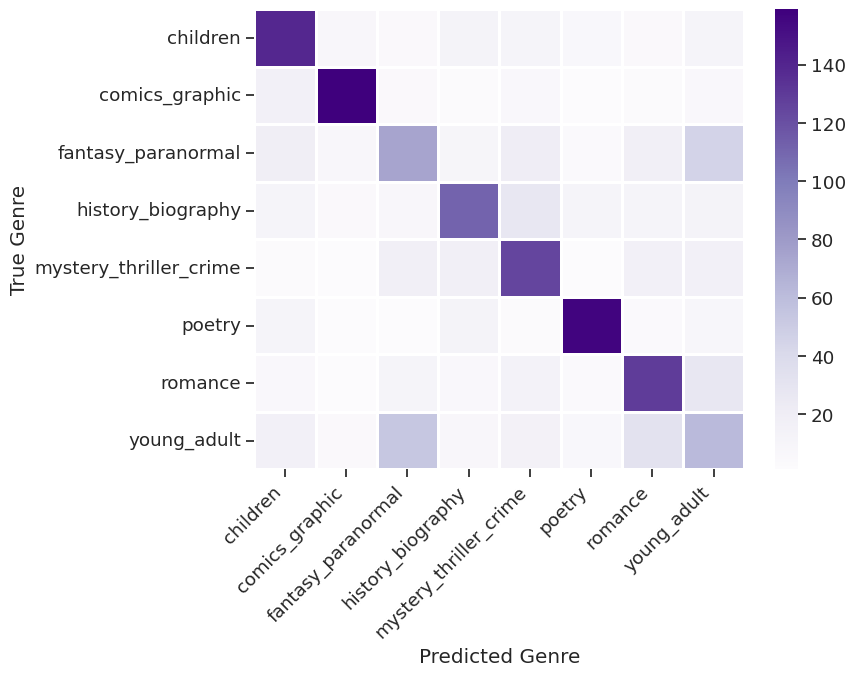

In [44]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [45]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

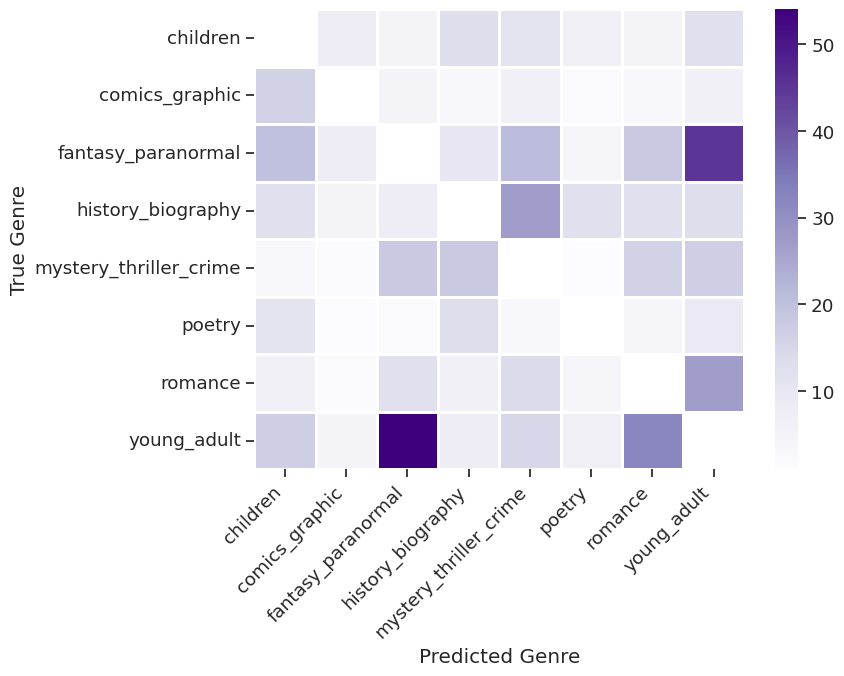

In [46]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [47]:
import json, wandb
from sklearn.metrics import classification_report

wandb.init()
# Run evaluation
eval_results = trainer.evaluate()
print(eval_results)
 
# Log final metrics to W&B
wandb.log({
    "final/loss":     eval_results["eval_loss"],
    "final/accuracy": eval_results["eval_accuracy"],
    "final/f1":       eval_results["eval_f1"],
})
 
# Save full classification report
preds  = trainer.predict(test_dataset).predictions.argmax(-1)
labels = [item["labels"].item() for item in test_dataset]
report = classification_report(
	labels, preds, target_names=list(id2label.values()), output_dict=True
)
 
with open("eval_report.json", "w") as f:
	json.dump(report, f, indent=2)
 
# Upload to W&B as a versioned Artifact
artifact = wandb.Artifact("eval-report", type="evaluation")
artifact.add_file("eval_report.json")
wandb.log_artifact(artifact)
wandb.finish()


wandb: Finishing previous runs because reinit is set to 'default'.
wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▆██
wandb:                 eval/f1 ▁▅██
wandb:               eval/loss █▁▁▁
wandb:            eval/runtime █▁▂▁
wandb: eval/samples_per_second ▁█▇█
wandb:   eval/steps_per_second ▁█▇█
wandb:           test/accuracy ▁
wandb:                 test/f1 ▁
wandb:               test/loss ▁
wandb:            test/runtime ▁
wandb:                      +7 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.5975
wandb:                 eval/f1 0.59575
wandb:               eval/loss 2.27199
wandb:            eval/runtime 13.2236
wandb: eval/samples_per_second 120.996
wandb:   eval/steps_per_second 1.891
wandb:           test/accuracy 0.5975
wandb:                 test/f1 0.59575
wandb:               test/loss 2.27199
wandb:            test/runtime 13.2326
wandb:                     +12 ...
wandb: 
wandb: 🚀 View run distilbert-run-1 a

Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,2.271987,0,0.597500,0.595749


{'eval_loss': 2.271987199783325, 'eval_accuracy': 0.5975, 'eval_f1': 0.5957487416148343}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


wandb: uploading artifact eval-report; updating run metadata
wandb: uploading artifact eval-report
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁
wandb:                 eval/f1 ▁
wandb:               eval/loss ▁
wandb:            eval/runtime ▁
wandb: eval/samples_per_second ▁
wandb:   eval/steps_per_second ▁
wandb:          final/accuracy ▁
wandb:                final/f1 ▁
wandb:              final/loss ▁
wandb:           test/accuracy ▁
wandb:                      +7 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.5975
wandb:                 eval/f1 0.59575
wandb:               eval/loss 2.27199
wandb:            eval/runtime 13.021
wandb: eval/samples_per_second 122.879
wandb:   eval/steps_per_second 1.92
wandb:          final/accuracy 0.5975
wandb:                final/f1 0.59575
wandb:              final/loss 2.27199
wandb:           test/accuracy 0.5975
wandb:                      +7 ...
wandb: 
wandb: 🚀 View run exalted-oath-5 at: https://wandb.ai/

In [48]:
import json, wandb
from sklearn.metrics import classification_report

wandb.init()

# Run evaluation
eval_results = trainer.evaluate()
print(eval_results)

# Log final metrics to W&B
wandb.log({
    "final/loss":     eval_results["eval_loss"],
    "final/accuracy": eval_results["eval_accuracy"],
    "final/f1":       eval_results["eval_f1"],
})

# Save full classification report
preds  = trainer.predict(test_dataset).predictions.argmax(-1)
labels = [item["labels"].item() for item in test_dataset]

report = classification_report(
    labels,
    preds,
    target_names=list(id2label.values()),
    output_dict=True
)

with open("eval_report.json", "w") as f:
    json.dump(report, f, indent=2)

# Upload to W&B as a versioned Artifact
artifact = wandb.Artifact("eval-report", type="evaluation")
artifact.add_file("eval_report.json")
wandb.log_artifact(artifact)

# Print Markdown Results Table
print("\n## Results\n")
print("| Metric | Score |")
print("|--------|-------|")
print(f"| Accuracy | {eval_results['eval_accuracy']:.2f} |")
print(f"| F1 Score | {eval_results['eval_f1']:.2f} |")
print(f"| Eval Loss | {eval_results['eval_loss']:.2f} |")

wandb.finish()

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260527_150829-n7emexqt
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run proud-haze-6
wandb: ⭐️ View project at https://wandb.ai/g25ait2080-iitjodhpur/uncategorized
wandb: 🚀 View run at https://wandb.ai/g25ait2080-iitjodhpur/uncategorized/runs/n7emexqt
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,2.271987,0,0.597500,0.595749


{'eval_loss': 2.271987199783325, 'eval_accuracy': 0.5975, 'eval_f1': 0.5957487416148343}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


wandb: uploading artifact eval-report; updating run metadata



## Results

| Metric | Score |
|--------|-------|
| Accuracy | 0.60 |
| F1 Score | 0.60 |
| Eval Loss | 2.27 |


wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁
wandb:                 eval/f1 ▁
wandb:               eval/loss ▁
wandb:            eval/runtime ▁
wandb: eval/samples_per_second ▁
wandb:   eval/steps_per_second ▁
wandb:          final/accuracy ▁
wandb:                final/f1 ▁
wandb:              final/loss ▁
wandb:           test/accuracy ▁
wandb:                      +7 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.5975
wandb:                 eval/f1 0.59575
wandb:               eval/loss 2.27199
wandb:            eval/runtime 12.9896
wandb: eval/samples_per_second 123.175
wandb:   eval/steps_per_second 1.925
wandb:          final/accuracy 0.5975
wandb:                final/f1 0.59575
wandb:              final/loss 2.27199
wandb:           test/accuracy 0.5975
wandb:                      +7 ...
wandb: 
wandb: 🚀 View run proud-haze-6 at: https://wandb.ai/g25ait2080-iitjodhpur/uncategorized/runs/n7emexqt
wandb: ⭐️ View project at: https://wandb.ai/g25ai

In [49]:
from huggingface_hub import login, create_repo
from kaggle_secrets import UserSecretsClient

# Load token from Kaggle Secrets
secrets = UserSecretsClient()
HF_TOKEN = secrets.get_secret("HF_TOKEN")

# Login
login(token=HF_TOKEN)

# Create repo first (safe even if already exists)
create_repo(
    repo_id="g25ait2080/MLOPSAssign2",
    repo_type="model",
    exist_ok=True,
    private=False
)

# ✅ CORRECT — only "username/repo-name", no URL prefix
model.push_to_hub("g25ait2080/MLOPSAssign2", token=HF_TOKEN)
tokenizer.push_to_hub("g25ait2080/MLOPSAssign2", token=HF_TOKEN)

print("✅ Model pushed to Hugging Face successfully!")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Model pushed to Hugging Face successfully!


In [50]:
import wandb

# Re-initialize W&B run if it was closed
if wandb.run is None:
    wandb.init(
        project="mlops-assignment2",   # use the same project name as before
        resume="allow"                 # resumes the last run if possible
    )

# Log HF model link
wandb.run.summary["huggingface_model"] = \
    "https://huggingface.co/g25ait2080/MLOPSAssign2"

print("✅ HF model link logged to W&B!")
print("🔗 Model URL: https://huggingface.co/g25ait2080/MLOPSAssign2")

wandb.finish()

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260527_150906-kuzepgir
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run crisp-meadow-11
wandb: ⭐️ View project at https://wandb.ai/g25ait2080-iitjodhpur/mlops-assignment2
wandb: 🚀 View run at https://wandb.ai/g25ait2080-iitjodhpur/mlops-assignment2/runs/kuzepgir
wandb: updating run metadata; uploading summary


✅ HF model link logged to W&B!
🔗 Model URL: https://huggingface.co/g25ait2080/MLOPSAssign2


wandb: 
wandb: Run summary:
wandb: huggingface_model https://huggingface....
wandb: 
wandb: 🚀 View run crisp-meadow-11 at: https://wandb.ai/g25ait2080-iitjodhpur/mlops-assignment2/runs/kuzepgir
wandb: ⭐️ View project at: https://wandb.ai/g25ait2080-iitjodhpur/mlops-assignment2
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260527_150906-kuzepgir/logs
